# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [119]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.preprocessing import OneHotEncoder


# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

APPLICATION = Path("..") / "data" / "raw" / "application_record.csv"          # PREENCHER: nome do arquivo
CREDIT = Path("..") / "data" / "raw" / "credit_record.csv"   
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [120]:
application_raw = pd.read_csv(APPLICATION)
credit = pd.read_csv(CREDIT)

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

#### Histórico de Crédito

In [121]:
print("Formato do dataset de crédito (qtde de linhas e colunas):", credit.shape)
credit.info()

Formato do dataset de crédito (qtde de linhas e colunas): (1048575, 3)
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


A coluna "STATUS", que traz o histórico de inadimplência mensal por cliente, é do tipo string. Para facilitar a criação da variável Target, pode ser necessário convertê-la.

In [122]:
print("\n* Verificação de dados nulos:\n",credit.isnull().sum())
print("\n* Verificação de linhas duplicadas:\n", credit.duplicated().sum())
print("\n* Quantidade de IDs (clientes) únicos:\n", credit['ID'].nunique())


* Verificação de dados nulos:
 ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

* Verificação de linhas duplicadas:
 0

* Quantidade de IDs (clientes) únicos:
 45985


A base de histórico de créditos não contém dados nulos ou linhas duplicadas. 
Vemos também que há apenas 45985 IDs únicos. Como a base tem 1048575 de registros, é possível dizer que, em média, cada cliente conta com um histórico de 23 meses. 

In [123]:
print ("\nEstatísticas do dataset de crédito:\n")
credit.describe().round(2).T


Estatísticas do dataset de crédito:



,count,mean,std,min,25%,50%,75%,max
ID,1048575.0,5068286.42,46150.58,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,-19.14,14.02,-60.0,-29.0,-17.0,-7.0,0.0


As estatísticas descritivas trazem informações interessantes:
- o registro de histórico de crédito mais longo é de 60 meses
- o registro de histórico de crédito mais curto é de 1 mês (no caso, o mês atual)
- a média de registro de histórico de crédito é de 19 meses

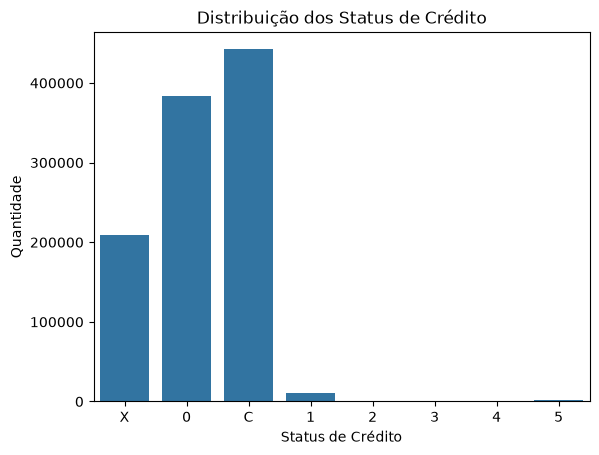


* Distribuição dos Status de Crédito:



STATUS
C    42.16
0    36.54
X    19.95
1     1.06
5     0.16
2     0.08
3     0.03
4     0.02
Name: proportion, dtype: float64

In [124]:
sns.countplot(x='STATUS', data=credit)
plt.title('Distribuição dos Status de Crédito')
plt.xlabel('Status de Crédito')
plt.ylabel('Quantidade')
plt.show()

print("\n* Distribuição dos Status de Crédito:\n")
credit['STATUS'].value_counts(normalize=True).round(4)* 100


Observando o dataset 'credit', agrupado por Status de crédito, nota-se que a maior parte dos registros (~62%) aponta para bom pagador (X: sem empréstimos e C: empréstimo pago no mês em análise). Cabe destacar que pode haver clientes repetidos na contagem, pois 1 cliente pode ter longo histórico de crédito.

In [125]:
#Criação das variáveis TARGET no dataset de crédito, para cada nível de atraso
credit['TARGET0'] = credit['STATUS'].apply(lambda x: 1 if x in ['0','1', '2', '3', '4', '5'] else 0)
credit['TARGET1'] = credit['STATUS'].apply(lambda x: 1 if x in ['1', '2', '3', '4', '5'] else 0)
credit['TARGET2'] = credit['STATUS'].apply(lambda x: 1 if x in ['2', '3', '4', '5'] else 0)
credit['TARGET3'] = credit['STATUS'].apply(lambda x: 1 if x in ['3', '4', '5'] else 0)
credit['TARGET4'] = credit['STATUS'].apply(lambda x: 1 if x in ['4', '5'] else 0)
credit['TARGET5'] = credit['STATUS'].apply(lambda x: 1 if x in ['5'] else 0)

target0 = credit.groupby('ID')['TARGET0'].max().reset_index()
target1 = credit.groupby('ID')['TARGET1'].max().reset_index()
target2 = credit.groupby('ID')['TARGET2'].max().reset_index()
target3 = credit.groupby('ID')['TARGET3'].max().reset_index()
target4 = credit.groupby('ID')['TARGET4'].max().reset_index()
target5 = credit.groupby('ID')['TARGET5'].max().reset_index()

pct_targets = pd.DataFrame({
    "Atraso >= 1 dia": target0['TARGET0'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 30 dias": target1['TARGET1'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 60 dias": target2['TARGET2'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 90 dias": target3['TARGET3'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 120 dias": target4['TARGET4'].value_counts(normalize=True).round(4) * 100,  
    "Atraso >= 150 dias": target5['TARGET5'].value_counts(normalize=True).round(4) * 100  
}).rename(index={0: "bom pagador (0)", 1: "mau pagador (1)"})

print("\n* Quantidade de IDs (clientes) únicos:\n", credit['ID'].nunique())

print("\n* Distribuição dos dados (em %) de acordo com o nível de atraso:")
display(pct_targets)


* Quantidade de IDs (clientes) únicos:
 45985

* Distribuição dos dados (em %) de acordo com o nível de atraso:


,Atraso >= 1 dia,Atraso >= 30 dias,Atraso >= 60 dias,Atraso >= 90 dias,Atraso >= 120 dias,Atraso >= 150 dias
bom pagador (0),12.95,88.37,98.55,99.28,99.47,99.58
mau pagador (1),87.05,11.63,1.45,0.72,0.53,0.42


Aqui, é trazida a análise diversos níveis para a classificação entre bons e maus pagadores, desde o mais rígido (atraso a partir de 1 dia) até o mais flexível (atraso maior ou igual a 150 dias), considerando o pior status de um cliente ao longo de seus registros de crédito. 

Nesse contexto, é possível observar que para atrasos maiores ou iguais a 30 dias, eleva-se a proporção de clientes indicados como bons pagadores. Nesse sentido, quanto mais flexível o nível de atraso, maior a chance de o modelo de aprendizado de máquina indicar como bom pagador um cliente alta chance de inadimplência. 

Por outro lado, atrasos entre 1 e 29 dias não necessariamente representam um risco iminente de inadimplência e quando adotado um critério mais rígido, o modelo de aprendizado de máquina pode indicar como mau pagador um cliente com baixas chances de inadimplência. 

Dessa forma, para o trabalho de aprendizado de máquina a ser desenvolvido neste projeto, será considerado como risco de aumento de inadimplência clientes com atrasos a partir de 30 dias (categoria 'TARGET1' no dataset 'credit'):
- Mau pagador (TARGET1 = 1): Clientes com algum registro de atraso de 30 dias ou mais (STATUS = 1, 2, 3, 4, 5) em algum mês do histórico de crédito
- Bom pagador (TARGET1 = 0): Clientes sem registro de atraso de 30 dias ou mais (STATUS = 0, C, X) em todos os meses do histórico de crédito

Olhando para a realidade do sistema financeiro atualmente, no geral se considera como crédito inadimplente atrasos > 90 dias. No contexto desta análise, foi considerado um critério mais rígido para maus pagadores, considerando qualquer atraso maior ou igual 30 dias - isso porque  que cartão faz parte de uma linha de crédito sem garantia e com juros elevados. No contexto brasileiro atual, de alto endividamento das famílias e índices de inadimplência em trajetória de crescimento, é importante ser mais conservador na análise, visando evitar elevação das provisões para perda esperada de crédito.

Verifica-se também que o dataframe Target está desbalanceado, sendo necessário refletir sobre técnicas de reamostragem ou ajuste de pesos antes de realizar a modelagem.

#### Cadastro do cliente (application)

In [126]:
print("Formato do dataset de cadastro (qtde de linhas e colunas):", application_raw.shape)
application_raw.info()

Formato do dataset de cadastro (qtde de linhas e colunas): (438557, 18)
<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PH

Alguns pontos de atenção nesta primeira visualização:
- Com base no histórico de crédito analisado anteriormente, vimos que há registro para 45985 clientes. No dataset de cadastro, há 438557 clientes. Isso dá indícios de que não há registro de crédito para todos os clientes do cadastro.
- É possível perceber que há dados nulos na coluna "OCCUPATION_TYPE", visto que a quantidade de registros é menor que o total de clientes.
- Há variáveis do tipo string. Neste caso, faz sentido utilizar técnicas de pré-processamento para convertê-las em variáveis numéricas para as análises posteriores.

In [127]:
print("\n* Verificação de dados nulos:\n", application_raw.isnull().sum())

print("\n* Verificação de linhas duplicadas:\n", application_raw.duplicated().sum())

print("\n* Quantidade de IDs (clientes) únicos:\n", application_raw['ID'].nunique())

print("\n* Quantidade de IDs duplicados:\n", application_raw["ID"].duplicated().sum())



* Verificação de dados nulos:
 ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

* Verificação de linhas duplicadas:
 0

* Quantidade de IDs (clientes) únicos:
 438510

* Quantidade de IDs duplicados:
 47


Pontos de atenção:
- Confirmamos que há dados nulos na coluna "OCCUPATION_TYPE". Uma solução possível é considerar o dado da coluna NAME_INCOME_TYPE. Outra alternativa seria marcar como "Desconhecido" os dados faltantes. 
- Verificou-se que a quantidade de IDs únicos é menor que a quantidade de clientes totais do dataset, tendo 47 registros duplicados. Isso indica mau preenchimento do registro, sendo necessário pensar em estratégia sobre como realizar o tratamento. 

In [128]:
print ("\nEstatísticas do dataset de cadastro:\n")
application_raw.describe().round(2).T


Estatísticas do dataset de cadastro:



,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6022176.27,571637.02,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,0.43,0.72,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,187524.29,110086.85,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-15997.90,4185.03,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,60563.68,138767.80,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,0.21,0.40,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,0.29,0.45,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,0.11,0.31,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.19,0.90,1.0,2.0,2.0,3.0,20.0


Analisando as estatísticas, são observados alguns pontos de atenção: 
- DAYS_BIRTH: converter para anos, para facilitar a anáise.
- DAYS_EMPLOYED: o valor máximo é de 365243. Pelo dicionário de dados, todos os valores positivos indicam que o cliente está desempregado. Nesse caso, cabe realizar um tratamento dos dados - talvez, indicar 0 para todos os valores positivos. Também vale converter para anos, para facilitar a análise


In [129]:
application_raw['DAYS_EMPLOYED'].value_counts().sort_index(ascending=False).head()

DAYS_EMPLOYED
 365243    75329
-12            8
-13           13
-16           18
-17            4
Name: count, dtype: int64

Aqui, verificamos que a maior parte dos clientes constam como desempregados (DAYS_EMPLOYED > 0)

In [130]:
application_raw[application_raw['OCCUPATION_TYPE'].isnull()]['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Pensioner               75357
Working                 35886
Commercial associate    16745
State servant            6210
Student                     5
Name: count, dtype: int64

Aqui, verificamos como estão distribuídos os grupos por tipo de renda. Na susbstituição de dados nulos da coluna "OCCUPATION_TYPE", será utilizado esse dado como substituto, pois é um indicativo de melhor descrição de ocupação do que "Desconhecido".

In [131]:
application_raw['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64

Aqui, vemos a distribuição dos dados por nível educacional. Para essa variável entrar na matriz de correlação, será necessário convertê-la em valor numérico.

In [132]:
application_raw['NAME_HOUSING_TYPE'].value_counts()

NAME_HOUSING_TYPE
House / apartment      393831
With parents            19077
Municipal apartment     14214
Rented apartment         5974
Office apartment         3922
Co-op apartment          1539
Name: count, dtype: int64

In [133]:
#Cruzamento da base de cadastro com a base de target
application_record = application_raw.drop_duplicates(subset="ID", keep="first")
application_merge = pd.merge(application_record, target1, on='ID', how='inner')
application_merge = application_merge.rename(columns={"TARGET1": "TARGET"})

print("\n* Quantidade de clientes únicos com cadastro ANTES do cruzamento:\n", application_raw['ID'].nunique())

print("\n* Quantidade clientes únicos com histórico de crédito:\n", credit['ID'].nunique())

print("\n* Quantidade de clientes únicos com cadastro APÓS o cruzamento:\n", application_merge['ID'].nunique())

print("\n* Clientes descartados da análise, com registro de crédito mas sem cadastro:\n", credit['ID'].nunique() - application_merge['ID'].nunique())

print("\n* Clientes descartados da análise, sem registro de crédito e com cadastro:\n", application_raw['ID'].nunique() - application_merge['ID'].nunique())

print("\n* Distribuição do Target APÓS o cruzamento:\n",application_merge['TARGET'].value_counts(normalize=True).round(4)* 100)
application_merge.head()



* Quantidade de clientes únicos com cadastro ANTES do cruzamento:
 438510

* Quantidade clientes únicos com histórico de crédito:
 45985

* Quantidade de clientes únicos com cadastro APÓS o cruzamento:
 36457

* Clientes descartados da análise, com registro de crédito mas sem cadastro:
 9528

* Clientes descartados da análise, sem registro de crédito e com cadastro:
 402053

* Distribuição do Target APÓS o cruzamento:
 TARGET
0    88.23
1    11.77
Name: proportion, dtype: float64


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


Após a definição do target e o cruzamento com a base de cadastro, observa-se que do universo de 438510 com cadastro, apenas 36457 tinham registro de crédito (~8%).

In [134]:
#Ajustando as variáveis DAYS_BIRTH e DAYS_EMPLOYED para anos, criando novas variáveis YEARS_BIRTH e YEARS_EMPLOYED
application_merge['YEARS_BIRTH'] = abs(application_merge['DAYS_BIRTH']) / 365

application_merge['YEARS_EMPLOYED'] = np.where(application_merge['DAYS_EMPLOYED'] < 0,abs(application_merge['DAYS_EMPLOYED']) / 365, 0)

#Adicionando a variável "FLAG_UNEMPLOYED", que indica se o cliente está desempregado (1) ou não (0), com base na variável DAYS_EMPLOYED.
application_merge['FLAG_UNEMPLOYED'] = np.where(application_merge['DAYS_EMPLOYED'] < 0, 0, 1)

#Ajustando a variável OCCUPATION_TYPE, que possui valores nulos, para o valor da variável NAME_INCOME_TYPE, quando OCCUPATION_TYPE for nulo. Caso contrário, mantém o valor original de OCCUPATION_TYPE. Criando uma nova variável chamada OCCUPATION_TYPE_ADJUSTED.
application_merge['OCCUPATION_TYPE_ADJUSTED'] = np.where(application_merge['OCCUPATION_TYPE'].isnull(),application_merge['NAME_INCOME_TYPE'], application_merge['OCCUPATION_TYPE'])

#Ajustandando as variáveis binárias de str para int
application_merge['CODE_GENDER_DUMMY'] = np.where(application_merge['CODE_GENDER'] == 'F', -1, 1)
application_merge['FLAG_OWN_CAR_DUMMY'] = np.where(application_merge['FLAG_OWN_CAR'] == 'Y', 1, 0)
application_merge['FLAG_OWN_REALTY_DUMMY'] = np.where(application_merge['FLAG_OWN_REALTY'] == 'Y', 1, 0)

#Ajustando a variável NAME_EDUCATION_TYPE para valores numéricos
application_merge['NAME_EDUCATION_TYPE_NUM'] = application_merge['NAME_EDUCATION_TYPE'].map(
{   'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
}
)



In [135]:
application_merge['OCCUPATION_TYPE_ADJUSTED'].value_counts(normalize=True).round(4) * 100

OCCUPATION_TYPE_ADJUSTED
Laborers                 17.04
Pensioner                16.84
Core staff                9.85
Sales staff               9.56
Working                   8.77
Managers                  8.26
Drivers                   5.86
Commercial associate      3.94
High skill tech staff     3.79
Accountants               3.40
Medicine staff            3.31
Cooking staff             1.80
Security staff            1.62
Cleaning staff            1.51
State servant             1.50
Private service staff     0.94
Low-skill Laborers        0.48
Waiters/barmen staff      0.48
Secretaries               0.41
HR staff                  0.23
Realty agents             0.22
IT staff                  0.16
Student                   0.00
Name: proportion, dtype: float64

Olhando a distribuição das profissões, observa-se que as 8 primeiras concentram 80% dos clientes, seguindo princípio de Pareto. Dessa forma, vamos fazer ajustes nessas coluna e aplicar a técnica de one hot encoding, transformando as variáveis categócias em valores numéricos.


In [136]:
#Agrupando profissisões para aplicação da técnica de one-hot encoding.
professions = [
    "Laborers",
    "Pensioner",
    "Core staff",
    "Sales staff",
    "Working",
    "Managers",
    "Drivers",
    "Commercial associate"
]

application_merge['OCCUPATION_TYPE_GROUPED'] = np.where(
    application_merge['OCCUPATION_TYPE_ADJUSTED'].isin(professions),
    application_merge['OCCUPATION_TYPE_ADJUSTED'],
    "Others"
)



In [137]:
#colunas a serem convertidas em variáveis dummy (one-hot encoding)
cols_one_hot = ['OCCUPATION_TYPE_GROUPED', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    drop=None  
)

encoded_array = ohe.fit_transform(application_merge[cols_one_hot])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cols_one_hot),
    index=application_merge.index
)

application_merge = pd.concat([application_merge, encoded_df], axis=1)

print(f"Total de novas colunas criadas: {encoded_df.shape[1]}")
encoded_df.head()


Total de novas colunas criadas: 20


,OCCUPATION_TYPE_GROUPED_Commercial associate,OCCUPATION_TYPE_GROUPED_Core staff,OCCUPATION_TYPE_GROUPED_Drivers,OCCUPATION_TYPE_GROUPED_Laborers,OCCUPATION_TYPE_GROUPED_Managers,OCCUPATION_TYPE_GROUPED_Others,OCCUPATION_TYPE_GROUPED_Pensioner,OCCUPATION_TYPE_GROUPED_Sales staff,OCCUPATION_TYPE_GROUPED_Working,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [138]:
application_merge.head(1).T

,0
ID,5008804
CODE_GENDER,M
FLAG_OWN_CAR,Y
FLAG_OWN_REALTY,Y
CNT_CHILDREN,0
AMT_INCOME_TOTAL,427500.0
NAME_INCOME_TYPE,Working
NAME_EDUCATION_TYPE,Higher education
NAME_FAMILY_STATUS,Civil marriage
NAME_HOUSING_TYPE,Rented apartment


## 2. Distribuição das variáveis

Neste passo, será considerado o dataset application_merge, que já contém a variável target para os 36457 clientes. 

#### Histograma & boxplot das variáveis numéricas do dataset de cadastro


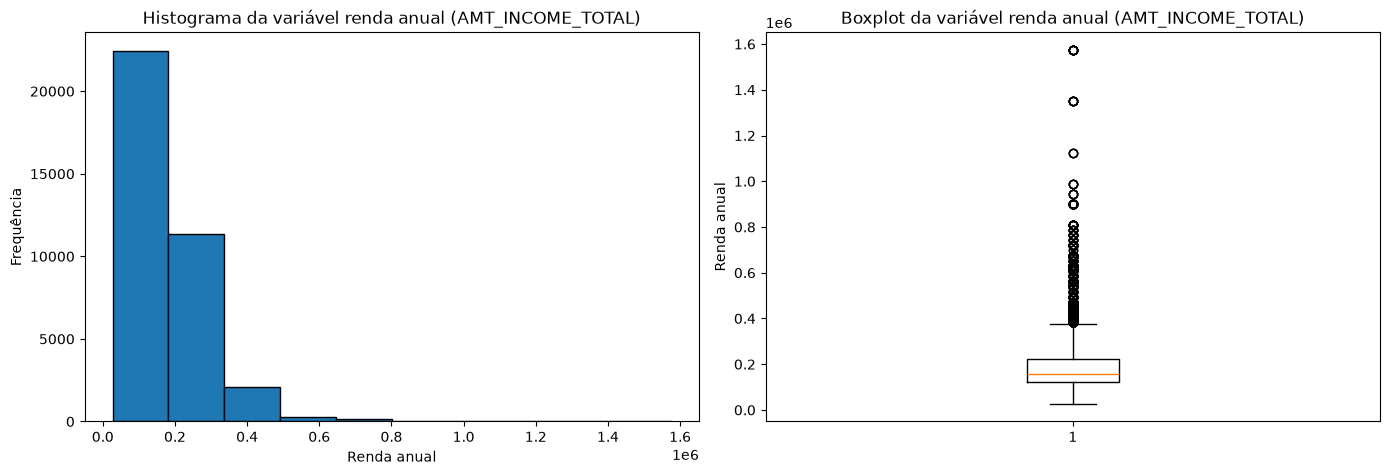

Maior frequência: AMT_INCOME_TOTAL
135000.0    4309
Name: count, dtype: int64
Maior Valor: 1575000.0


In [139]:
#Renda anual
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(application_merge['AMT_INCOME_TOTAL'], bins=10, edgecolor='black')
ax[0].set_ylabel('Frequência')
ax[0].set_xlabel('Renda anual')
ax[0].set_title('Histograma da variável renda anual (AMT_INCOME_TOTAL)')

ax[1].boxplot(application_merge['AMT_INCOME_TOTAL'])
ax[1].set_ylabel('Renda anual')
ax[1].set_title('Boxplot da variável renda anual (AMT_INCOME_TOTAL)')

plt.tight_layout()
plt.show()

print("Maior frequência:", application_merge['AMT_INCOME_TOTAL'].value_counts().head(1))
print("Maior Valor:",application_merge['AMT_INCOME_TOTAL'].max())

Quanto à renda anual, o histograma indica uma curva assimétrica à direita, com a maior quantidade concentrada em $135000. No boxplot, são observados também outliers - destaque para o maior valor de renda anual, de $1575000.



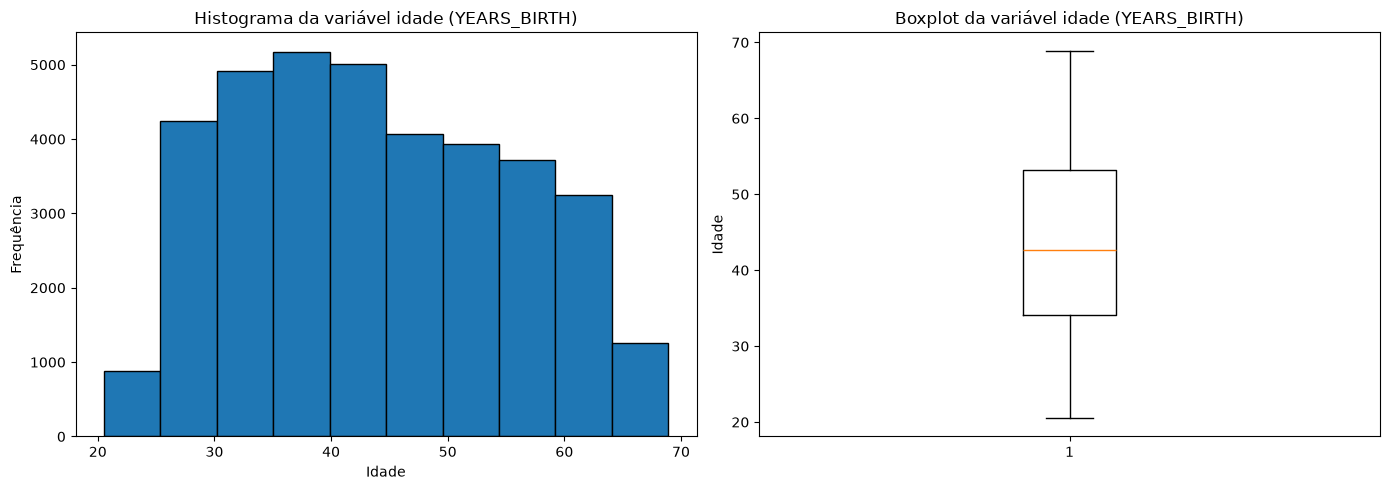

Maior frequência: YEARS_BIRTH
42.517808    54
34.728767    54
46.290411    38
Name: count, dtype: int64
Maior Valor: 68.90958904109588


In [140]:
#Idade
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(application_merge['YEARS_BIRTH'], bins=10, edgecolor='black')
ax[0].set_ylabel('Frequência')
ax[0].set_xlabel('Idade')
ax[0].set_title('Histograma da variável idade (YEARS_BIRTH)')

ax[1].boxplot(application_merge['YEARS_BIRTH'])
ax[1].set_ylabel('Idade')
ax[1].set_title('Boxplot da variável idade (YEARS_BIRTH)')

plt.tight_layout()
plt.show()

print("Maior frequência:", application_merge['YEARS_BIRTH'].value_counts().head(3))
print("Maior Valor:",application_merge['YEARS_BIRTH'].max())

Quanto à idade, o histograma aparenta uma distribuição normal, com concentração maior entre 34 e 46 anos. No boxplot, não observamos outliers.

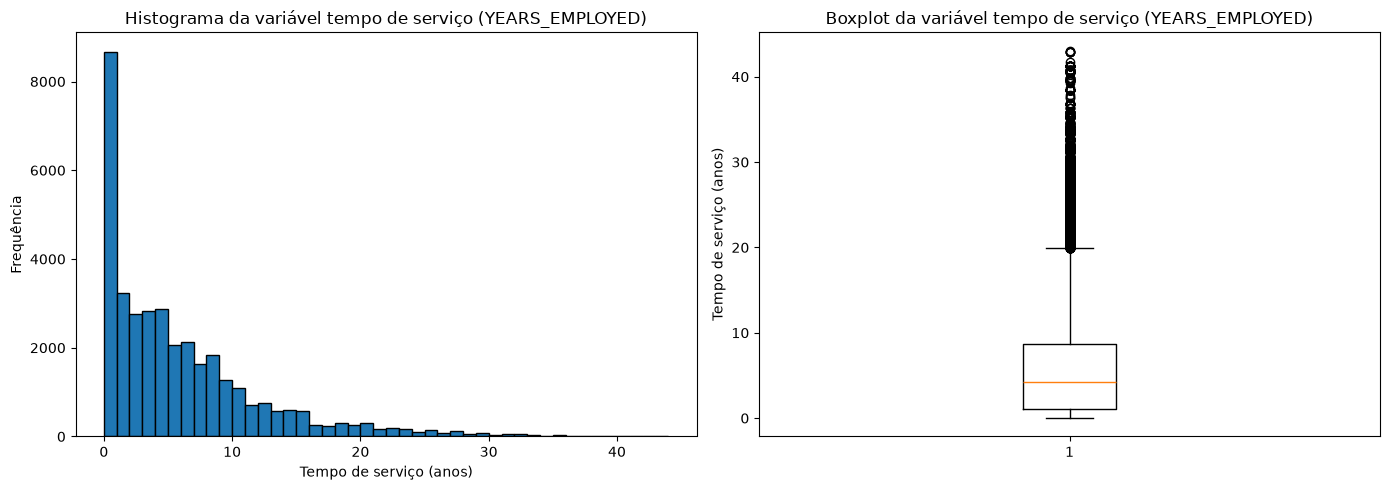

Maior frequência: YEARS_EMPLOYED
0.0    6135
Name: count, dtype: int64
Maior Valor: 43.04931506849315


In [141]:
#Tempo de serviço
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(application_merge['YEARS_EMPLOYED'], bins=np.arange(0, application_merge['YEARS_EMPLOYED'].max() + 1), edgecolor='black')
ax[0].set_ylabel('Frequência')
ax[0].set_xlabel('Tempo de serviço (anos)')
ax[0].set_title('Histograma da variável tempo de serviço (YEARS_EMPLOYED)')

ax[1].boxplot(application_merge['YEARS_EMPLOYED'])
ax[1].set_ylabel('Tempo de serviço (anos)')
ax[1].set_title('Boxplot da variável tempo de serviço (YEARS_EMPLOYED)')

plt.tight_layout()
plt.show()

print("Maior frequência:", application_merge['YEARS_EMPLOYED'].value_counts().head(1))
print("Maior Valor:",application_merge['YEARS_EMPLOYED'].max())

Em relação ao tempo de serviço, pelo histograma nota-se uma curva assimétrica à direita, com a maior parte dos clientes como desempregado (YEARS_EMPLOYED = 0), que pode indicar risco à inadimplência.
No boxplot, são observados outliers também, sendo 43 anos o maior tempo de serviço.

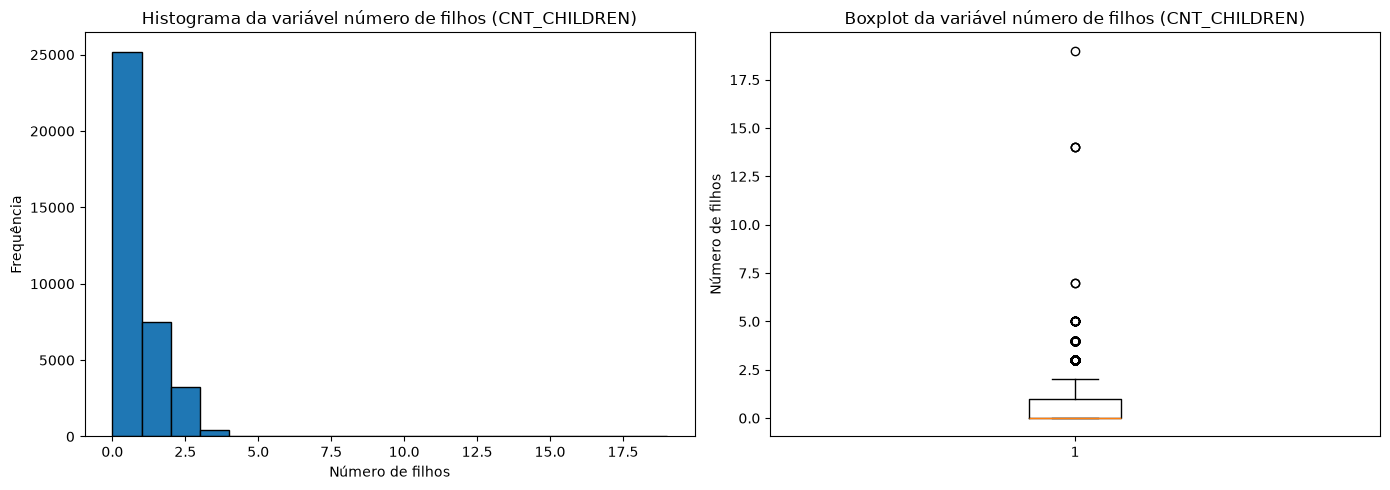

Maior frequência: CNT_CHILDREN
0    25201
Name: count, dtype: int64
Maior Valor: 19


In [142]:
#Número de filhos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(application_merge['CNT_CHILDREN'], bins=np.arange(0, application_merge['CNT_CHILDREN'].max() + 1), edgecolor='black')
ax[0].set_ylabel('Frequência')
ax[0].set_xlabel('Número de filhos')
ax[0].set_title('Histograma da variável número de filhos (CNT_CHILDREN)')

ax[1].boxplot(application_merge['CNT_CHILDREN'])
ax[1].set_ylabel('Número de filhos')
ax[1].set_title('Boxplot da variável número de filhos (CNT_CHILDREN)')

plt.tight_layout()
plt.show()

print("Maior frequência:", application_merge['CNT_CHILDREN'].value_counts().head(1))
print("Maior Valor:",application_merge['CNT_CHILDREN'].max())

Sobre o número de filhos, o histograma mostra uma curva assimétrica à direita, com a maioria dos clientes sem filhos. No boxplot, observamos alguns outliers, sendo o maior 19 filhos - isso pode ser indício de um registro mal feito. 

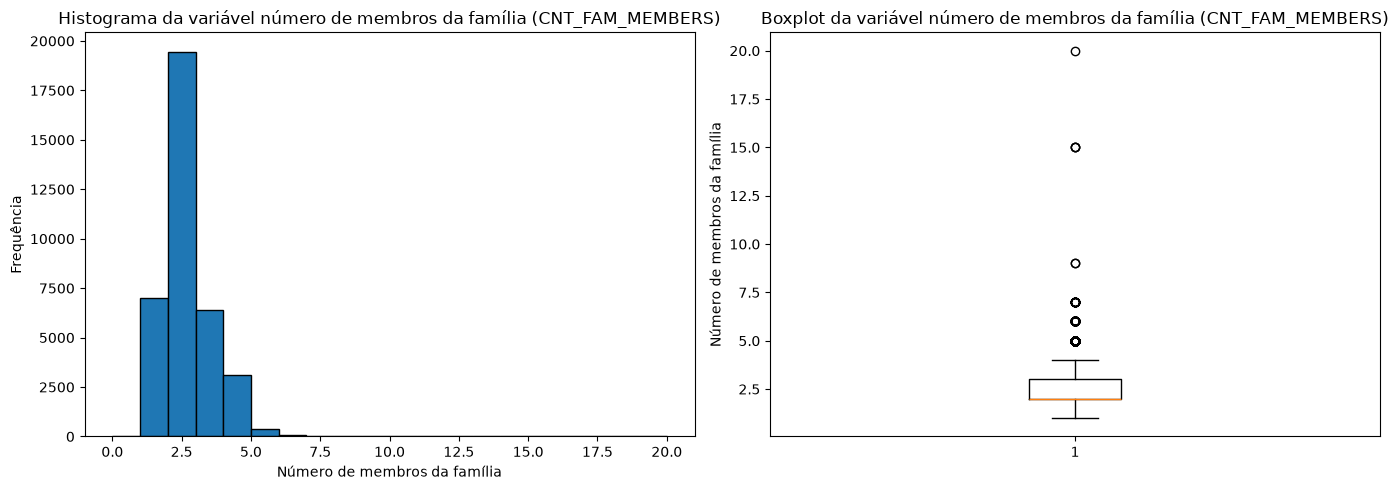

Maior frequência: CNT_FAM_MEMBERS
2.0    19463
Name: count, dtype: int64
Maior Valor: 20.0


In [143]:
#Número de membros da família
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(application_merge['CNT_FAM_MEMBERS'], bins=np.arange(0, application_merge['CNT_FAM_MEMBERS'].max() + 1), edgecolor='black')
ax[0].set_ylabel('Frequência')
ax[0].set_xlabel('Número de membros da família')
ax[0].set_title('Histograma da variável número de membros da família (CNT_FAM_MEMBERS)')

ax[1].boxplot(application_merge['CNT_FAM_MEMBERS'])
ax[1].set_ylabel('Número de membros da família')
ax[1].set_title('Boxplot da variável número de membros da família (CNT_FAM_MEMBERS)')

plt.tight_layout()
plt.show()

print("Maior frequência:", application_merge['CNT_FAM_MEMBERS'].value_counts().head(1))
print("Maior Valor:",application_merge['CNT_FAM_MEMBERS'].max())

Sobre o tamanho da família, observa-se que é uma curva assimétrica à direita, com a maior parte das famílias compostas por 2 membros. O boxplot aponta outliers também, sendo a família mais numerosa com 20 membros. 

#### Gráficos das variáveis categóricas do dataset de cadastro

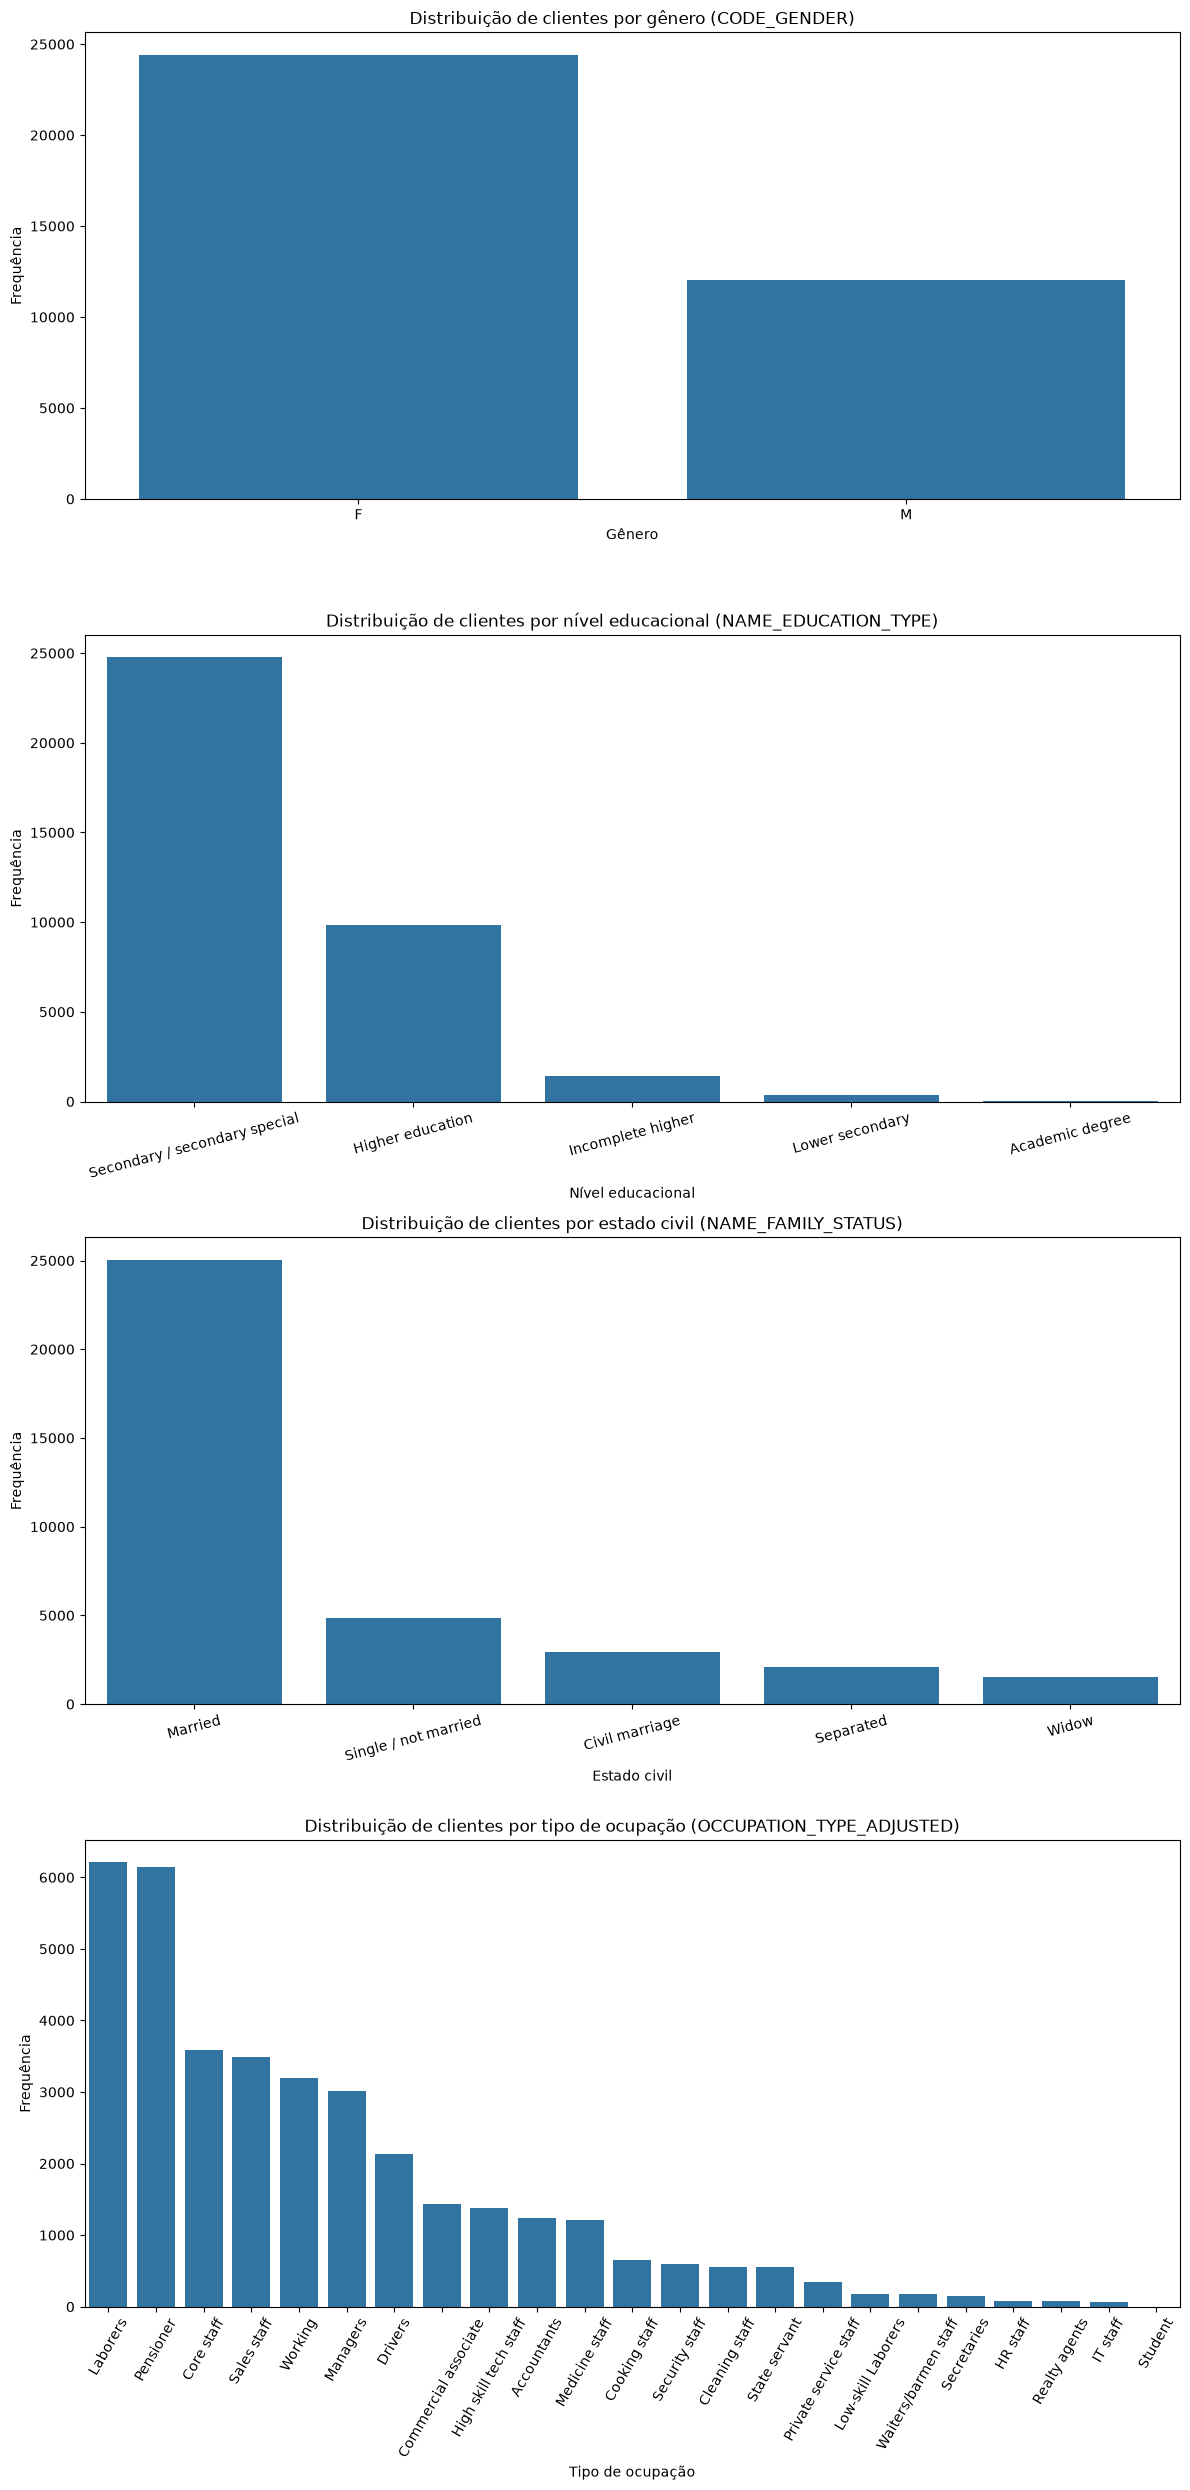

CODE_GENDER
F    67.01
M    32.99
Name: proportion, dtype: float64 

NAME_EDUCATION_TYPE
Secondary / secondary special    67.96
Higher education                 27.06
Incomplete higher                 3.87
Lower secondary                   1.03
Academic degree                   0.09
Name: proportion, dtype: float64 

NAME_FAMILY_STATUS
Married                 68.71
Single / not married    13.25
Civil marriage           8.08
Separated                5.77
Widow                    4.20
Name: proportion, dtype: float64 

OCCUPATION_TYPE_ADJUSTED
Laborers                 17.04
Pensioner                16.84
Core staff                9.85
Sales staff               9.56
Working                   8.77
Managers                  8.26
Drivers                   5.86
Commercial associate      3.94
High skill tech staff     3.79
Accountants               3.40
Medicine staff            3.31
Cooking staff             1.80
Security staff            1.62
Cleaning staff            1.51
State servant     

In [144]:
fig, axes = plt.subplots(4, 1, figsize=(12,25))

#axes = ax.flatten()

sns.countplot(x='CODE_GENDER', data=application_merge, ax=axes[0], order=application_merge['CODE_GENDER'].value_counts().index)
axes[0].set_ylabel('Frequência')
axes[0].set_xlabel('Gênero')
axes[0].set_title('Distribuição de clientes por gênero (CODE_GENDER)')

sns.countplot(x='NAME_EDUCATION_TYPE', data=application_merge, ax=axes[1], order=application_merge['NAME_EDUCATION_TYPE'].value_counts().index)
axes[1].set_ylabel('Frequência')
axes[1].set_xlabel('Nível educacional')
axes[1].set_title('Distribuição de clientes por nível educacional (NAME_EDUCATION_TYPE)')
axes[1].tick_params(axis='x', rotation=15)

sns.countplot(x='NAME_FAMILY_STATUS', data=application_merge, ax=axes[2], order=application_merge['NAME_FAMILY_STATUS'].value_counts().index)
axes[2].set_ylabel('Frequência')
axes[2].set_xlabel('Estado civil')
axes[2].set_title('Distribuição de clientes por estado civil (NAME_FAMILY_STATUS)')
axes[2].tick_params(axis='x', rotation=15)


sns.countplot(x='OCCUPATION_TYPE_ADJUSTED', data=application_merge, ax=axes[3], order=application_merge['OCCUPATION_TYPE_ADJUSTED'].value_counts().index)
axes[3].set_ylabel('Frequência')
axes[3].set_xlabel('Tipo de ocupação')
axes[3].set_title('Distribuição de clientes por tipo de ocupação (OCCUPATION_TYPE_ADJUSTED)')
axes[3].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

print(application_merge['CODE_GENDER'].value_counts(normalize=True).round(4) * 100, "\n")
print(application_merge['NAME_EDUCATION_TYPE'].value_counts(normalize=True).round(4) * 100, "\n")
print(application_merge['NAME_FAMILY_STATUS'].value_counts(normalize=True).round(4) * 100, "\n")
print(application_merge['OCCUPATION_TYPE_ADJUSTED'].value_counts(normalize=True).round(4) * 100, "\n")

Em relação ao gênero, 67% dos cllientes é do sexo feminino. 
Quanto ao nível educacional, 68% possui Ensino Médio (Secondary/Secondary special).
Sobre o estado civil, observa-se que 69% dos clientes da base é composta de pessoas casadas - o que se relaciona com o tamanho das famílias visto no histograma, composta por 2 pessoas. 
Quanto ao tipo de ocupação, observa-se maior concentração de clientes como Trabalhadores (Laborers) e Pensionistas/Aposentados (Pensioners). 


#### Análise das features com Target

C:\Users\User\AppData\Local\Temp\ipykernel_14848\618227659.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=application_merge, palette = 'hls', ax=axes[0])
C:\Users\User\AppData\Local\Temp\ipykernel_14848\618227659.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y='YEARS_BIRTH', data=application_merge, palette = 'hls', ax=axes[1])
C:\Users\User\AppData\Local\Temp\ipykernel_14848\618227659.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y='YEARS_EMPLOYED', data=applica

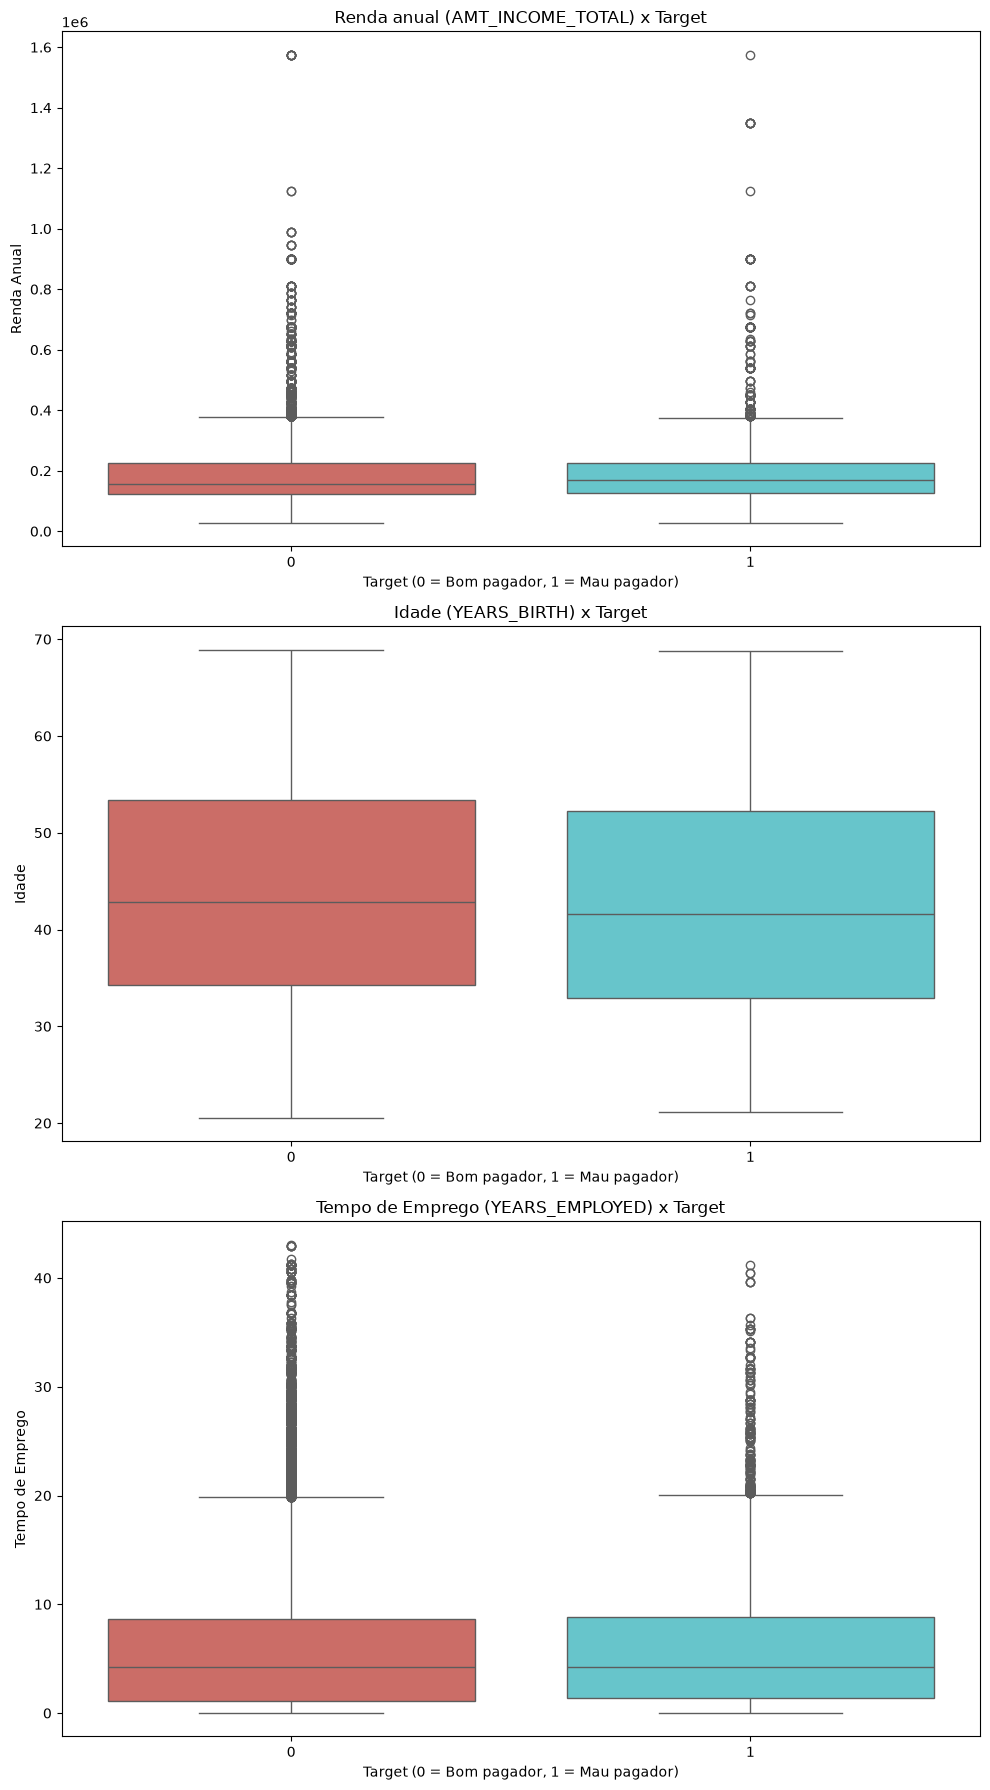

In [150]:
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=application_merge, palette = 'hls', ax=axes[0])
axes[0].set_title('Renda anual (AMT_INCOME_TOTAL) x Target')
axes[0].set_xlabel('Target (0 = Bom pagador, 1 = Mau pagador)')
axes[0].set_ylabel('Renda Anual')

sns.boxplot(x='TARGET', y='YEARS_BIRTH', data=application_merge, palette = 'hls', ax=axes[1])
axes[1].set_title('Idade (YEARS_BIRTH) x Target')
axes[1].set_xlabel('Target (0 = Bom pagador, 1 = Mau pagador)')
axes[1].set_ylabel('Idade')

sns.boxplot(x='TARGET', y='YEARS_EMPLOYED', data=application_merge, palette = 'hls', ax=axes[2])
axes[2].set_title('Tempo de Emprego (YEARS_EMPLOYED) x Target')
axes[2].set_xlabel('Target (0 = Bom pagador, 1 = Mau pagador)')
axes[2].set_ylabel('Tempo de Emprego')

plt.tight_layout()
plt.show()

Sobre a renda anual do cliente, observa-se que a distribuição entre as classes é similar. Isso pode trazer um indício de que a renda, isoladamente, não é um preditor adequado para classificar o cliente como bom ou mau pagador. 
Em relação à idade, observa-se para maus pagadores, a mediana é um pouco menor quando comparada aos bons pagadores. Nesse contexto, é possível inferir que maus pagadores tendem a ser mais jovens em relação a bons pagadores. 
Quanto ao tempo de serviço, também se observa uma distribuição similar entre as classes.

#### Análise de variáveis categóricas com Target

In [146]:
pd.crosstab(application_merge['CODE_GENDER'], application_merge['TARGET'], normalize='index') * 100

TARGET,0,1
CODE_GENDER,,
F,88.710602,11.289398
M,87.253679,12.746321


Em relação ao gênero, observa-se que no gênero masculino, a proporção de maus pagadores é maior do que no gênero feminino.

In [147]:
pd.crosstab(application_merge['NAME_EDUCATION_TYPE'], application_merge['TARGET'], normalize='index') * 100

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,78.125000,21.875000
Higher education,88.361719,11.638281
Incomplete higher,85.319149,14.680851
Lower secondary,89.572193,10.427807
Secondary / secondary special,88.335957,11.664043


Em relação ao nível educional, observa-se que dentre o clientes com pós-graduação (Academic degree) observa-se uma proporção maior de maus pagadores (~22%)

In [148]:
pd.crosstab(application_merge['NAME_FAMILY_STATUS'], application_merge['TARGET'], normalize='index') * 100

TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,87.538200,12.461800
Married,88.366337,11.633663
Separated,89.300999,10.699001
Single / not married,87.098778,12.901222
Widow,89.425587,10.574413


Pelo estado civil, observa-se que o grupo de solteiros/não casados conta com a maior proporção de maus pagadores (~13%)

In [149]:
pd.crosstab(application_merge['OCCUPATION_TYPE_ADJUSTED'], application_merge['TARGET'], normalize='index') * 100

TARGET,0,1
OCCUPATION_TYPE_ADJUSTED,,
Accountants,88.154714,11.845286
Cleaning staff,88.566243,11.433757
Commercial associate,88.038943,11.961057
Cooking staff,86.870229,13.129771
Core staff,87.106656,12.893344
Drivers,87.652011,12.347989
HR staff,83.529412,16.470588
High skill tech staff,86.912509,13.087491
IT staff,81.666667,18.333333


In [ ]:
application_merge['OCCUPATION_TYPE_ADJUSTED'].value_counts().sort_values(ascending=True).head(10)

Em relação à ocupação, o grupo de estudantes tem uma proporção de 100% de mau pagador. No entanto, cabe ressaltar que temos apenas 1 cliente como estudante no dataset application_merge, uma amostra pequena diante dos mais de 36 mil clientes. 

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [ ]:
# heatmap de correlação

In [ ]:
df_heatmap = application_merge.drop(columns=['ID', 'DAYS_BIRTH', 'NAME_INCOME_TYPE','DAYS_EMPLOYED', 'FLAG_MOBIL','OCCUPATION_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE_ADJUSTED', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE_GROUPED'])


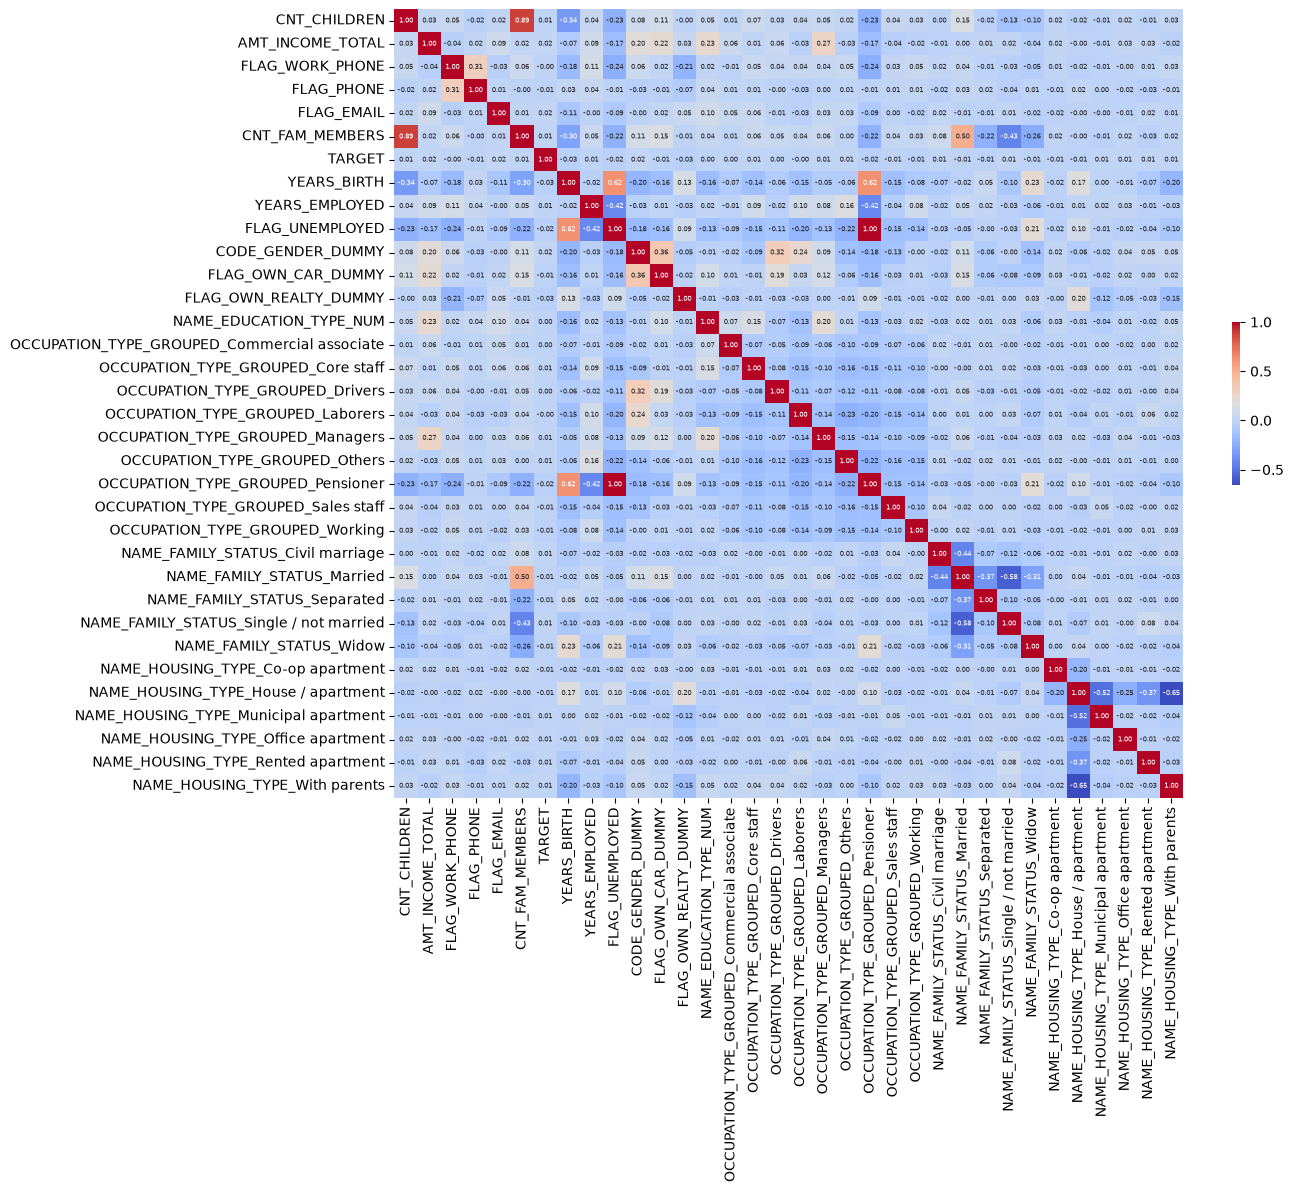

In [151]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    df_heatmap.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    annot_kws={"size": 5},
    cbar_kws={"shrink": .2}
)

plt.tight_layout()
plt.show()

O mapa de calor traz aspectos interessantes:
- forte correlação positiva entre quantidade de filhos (CNT_CHILDREN) e quantidade de membros da família (CNT_FAM_MEMBERS). Para mitigar vieses na modelagem, cabe excluir uma dessas variáveis da análise.
- também se observa correlação negativa entre número de filhos (CNT_CHILDREN) e idade do cliente (YEARS_BIRTH). Pode ser uma solução desconsiderar a quantidade de filhos do modelo.
- com a variável Target, não foram observadas correlações fortes. Aqui, cabe lembrar que trata-se de análise de correlação linear e as variáveis podem estar relacionadas de forma não linear. Nesse sentido, a primeira ideia é rodar os modelos de aprendizado de máquina com todas as variáveis. 

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

Nas análises realizadas anteriormente, foram observados outliers especialmente em renda, tempo de serviço, número de filhos e quantidade de membros da família. 
Para este projeto, optou-se por manter os outliers e na etapa de pré-processamento, utilizar técnicas de padronização para o treinamento dos modelos. 

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

In [117]:
print("\n* Distribuição do Target ANTES do cruzamento de bases:\n",target1['TARGET1'].value_counts(normalize=True).round(4) * 100)


print("\n* Distribuição do Target APÓS o cruzamento (dataset application_merge):\n",application_merge['TARGET'].value_counts(normalize=True).round(4)* 100)


* Distribuição do Target ANTES do cruzamento de bases:
 TARGET1
0    88.37
1    11.63
Name: proportion, dtype: float64

* Distribuição do Target APÓS o cruzamento (dataset application_merge):
 TARGET
0    88.23
1    11.77
Name: proportion, dtype: float64


Analisando a variável target, observa-se um desbalanceamento das classes, com ~12% dos clientes considerados mau pagadores e ~88% como bom pagadores.
Dado esse desbalanceamento, a acurácia não será a melhor métrica para avaliação dos modelos de aprendizado de máquina. Na avaliação, será necessário olhar também para Recall, F1 Score e Matriz de Confusão. 
Também será necessário pensar em técnicas para contornar esse desbalanceamento das classes.

In [ ]:
PROCESSED.mkdir(parents=True, exist_ok=True)
application_merge.to_csv(PROCESSED / "application_merge.csv", index=False)

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._

Os pontos de destaque da análise exploratória dos dados são elencados a seguir:
- A base de dados utilizada se mostra desbalanceada, com 88% considerados como bons pagadores. Nessa situação, a métrica de acurácia dos modelos preditivos perde seu valor, sendo necessário olhar para outras alternativas, como recall e f1-score. 
- Na análise bivariada, observa-se que homens, pessoas solteiras/não casadas e trabalhadores com baixa qualificação são indicados como piores pagadores.
- Na análise de correlação, nota-se forte correlação entre número de filhos e quantidade de membros da família. 